In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "games.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "datasnaek/chess",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/var/folders/x2/zzlc6gjx425_qfb3j1dh0s6w0000gn/T/ipykernel_4193/292403250.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:          id  rated    created_at  last_move_at  turns victory_status winner  \
0  TZJHLljE  False  1.504210e+12  1.504210e+12     13      outoftime  white   
1  l1NXvwaE   True  1.504130e+12  1.504130e+12     16         resign  black   
2  mIICvQHh   True  1.504130e+12  1.504130e+12     61           mate  white   
3  kWKvrqYL   True  1.504110e+12  1.504110e+12     61           mate  white   
4  9tXo1AUZ   True  1.504030e+12  1.504030e+12     95           mate  white   

  increment_code       white_id  white_rating      black_id  black_rating  \
0           15+2       bourgris          1500          a-00          1191   
1           5+10           a-00          1322     skinnerua          1261   
2           5+10         ischia          1496          a-00          1500   
3           20+0  daniamurashov          1439  adivanov2009          1454   
4           30+3      nik221107          1523  adivanov2009          1469   

                                             

In [2]:
X = df.drop(columns=[
    'id', 'white_id', 'black_id', 
    'moves', 'created_at', 'last_move_at',
    'winner'
])

y = df['winner']


In [3]:
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','bool']).columns.tolist()

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: ['turns', 'white_rating', 'black_rating', 'opening_ply']
Categorical: ['rated', 'victory_status', 'increment_code', 'opening_eco', 'opening_name']


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [5]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [6]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin

class ChessFeatureTransformer(BaseEstimator, TransformerMixin):

    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()
        X["rating_diff"] = X["white_rating"] - X["black_rating"]
        X["abs_rating_diff"] = abs(X["rating_diff"])
        X["increment_base"] = X["increment_code"].apply(lambda x: int(x.split('+')[0]))
        X["increment_bonus"] = X["increment_code"].apply(lambda x: int(x.split('+')[1]))

        return X

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

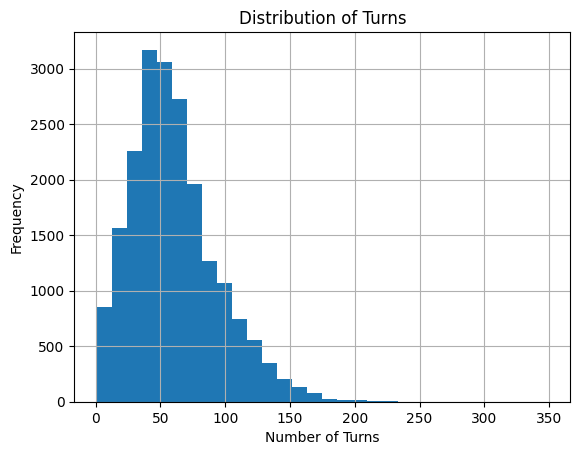

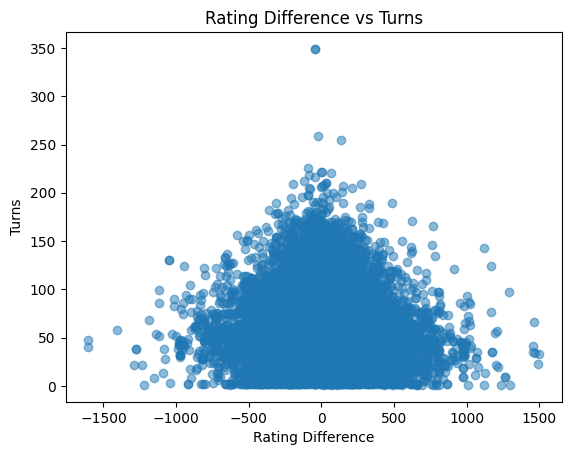

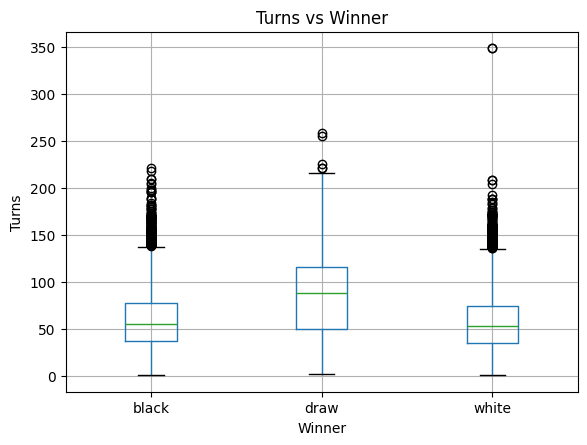

In [10]:
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

model_pipeline = Pipeline([
    ('features', ChessFeatureTransformer()),
    ('preprocessing', preprocessor),
    ('model', LinearSVC(class_weight='balanced', max_iter=7000))
])

model_pipeline2 = Pipeline([
    ('features', ChessFeatureTransformer()),
    ('preprocessing', preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ))
])

model_pipeline3 = Pipeline([
    ('features', ChessFeatureTransformer()),
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(
    n_estimators=800,
    max_depth=20,
    class_weight='balanced'
))
])
from xgboost import XGBClassifier

model_pipeline4 = Pipeline([
    ('features', ChessFeatureTransformer()),
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(
        n_estimators=900,
        learning_rate=0.1,
        max_depth=9,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42
    ))
])
import matplotlib.pyplot as plt

# Add rating_diff and related columns for plotting
df["rating_diff"] = df["white_rating"] - df["black_rating"]
df["abs_rating_diff"] = abs(df["rating_diff"])
df["increment_base"] = df["increment_code"].apply(lambda x: int(x.split('+')[0]))
df["increment_bonus"] = df["increment_code"].apply(lambda x: int(x.split('+')[1]))

df["turns"].hist(bins=30)
plt.title("Distribution of Turns")
plt.xlabel("Number of Turns")
plt.ylabel("Frequency")
plt.show()

plt.scatter(df["rating_diff"], df["turns"], alpha=0.5)
plt.title("Rating Difference vs Turns")
plt.xlabel("Rating Difference")
plt.ylabel("Turns")
plt.show()

df.boxplot(column="turns", by="winner")
plt.title("Turns vs Winner")
plt.suptitle("")   
plt.xlabel("Winner")
plt.ylabel("Turns")
plt.show()


model_pipeline.fit(X_train, y_train)
model_pipeline2.fit(X_train,y_train)
model_pipeline3.fit(X_train,y_train)
model_pipeline4.fit(X_train,y_train)

y_pred = model_pipeline.predict(X_test)
y_pred2=model_pipeline2.predict(X_test)
y_pred3=model_pipeline3.predict(X_test)
y_pred4=model_pipeline4.predict(X_test)



In [11]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred4))

print("Accuracy:", accuracy_score(y_test, y_pred4))

print(classification_report(y_test, y_pred4))


[[1600    0  216]
 [   6  181    5]
 [ 191    2 1811]]
Accuracy: 0.8953140578265204
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      1816
           1       0.99      0.94      0.97       192
           2       0.89      0.90      0.90      2004

    accuracy                           0.90      4012
   macro avg       0.92      0.91      0.92      4012
weighted avg       0.90      0.90      0.90      4012



In [12]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred3))

print("Accuracy:", accuracy_score(y_test, y_pred3))

print(classification_report(y_test, y_pred3))


[[1169    7  640]
 [   7  185    0]
 [ 662    3 1339]]
Accuracy: 0.6712362911266201
              precision    recall  f1-score   support

           0       0.64      0.64      0.64      1816
           1       0.95      0.96      0.96       192
           2       0.68      0.67      0.67      2004

    accuracy                           0.67      4012
   macro avg       0.75      0.76      0.76      4012
weighted avg       0.67      0.67      0.67      4012



In [13]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred2))

print("Accuracy:", accuracy_score(y_test, y_pred2))

print(classification_report(y_test, y_pred2))

[[1340    1  475]
 [  10  181    1]
 [ 348    1 1655]]
Accuracy: 0.7916251246261217
              precision    recall  f1-score   support

           0       0.79      0.74      0.76      1816
           1       0.99      0.94      0.97       192
           2       0.78      0.83      0.80      2004

    accuracy                           0.79      4012
   macro avg       0.85      0.84      0.84      4012
weighted avg       0.79      0.79      0.79      4012



In [14]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

[[1113    6  697]
 [   6  183    3]
 [ 633    2 1369]]
Accuracy: 0.6642572283150548
              precision    recall  f1-score   support

           0       0.64      0.61      0.62      1816
           1       0.96      0.95      0.96       192
           2       0.66      0.68      0.67      2004

    accuracy                           0.66      4012
   macro avg       0.75      0.75      0.75      4012
weighted avg       0.66      0.66      0.66      4012



In [15]:
from sklearn.metrics import classification_report

print("Gradient Boosting Report")

print(classification_report(y_test,y_pred2))

print("XGBoost Report")

print(classification_report(y_test,y_pred4))

Gradient Boosting Report
              precision    recall  f1-score   support

           0       0.79      0.74      0.76      1816
           1       0.99      0.94      0.97       192
           2       0.78      0.83      0.80      2004

    accuracy                           0.79      4012
   macro avg       0.85      0.84      0.84      4012
weighted avg       0.79      0.79      0.79      4012

XGBoost Report
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      1816
           1       0.99      0.94      0.97       192
           2       0.89      0.90      0.90      2004

    accuracy                           0.90      4012
   macro avg       0.92      0.91      0.92      4012
weighted avg       0.90      0.90      0.90      4012



GB Confusion Matrix
[[1340    1  475]
 [  10  181    1]
 [ 348    1 1655]]
XGB Confusion Matrix
[[1600    0  216]
 [   6  181    5]
 [ 191    2 1811]]


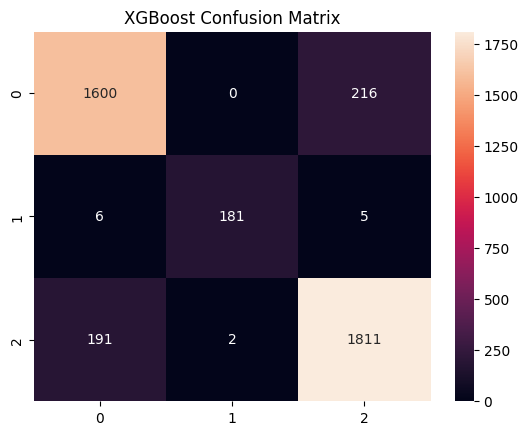

In [16]:
from sklearn.metrics import confusion_matrix

print("GB Confusion Matrix")

print(confusion_matrix(y_test,y_pred2))

print("XGB Confusion Matrix")

print(confusion_matrix(y_test,y_pred4))
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
confusion_matrix(y_test,y_pred4),
annot=True,
fmt='d'
)

plt.title("XGBoost Confusion Matrix")

plt.show()

In [17]:
y_pred2 = model_pipeline2.predict(X_test)

y_pred4 = model_pipeline4.predict(X_test)

y_prob2 = model_pipeline2.predict_proba(X_test)

y_prob4 = model_pipeline4.predict_proba(X_test)

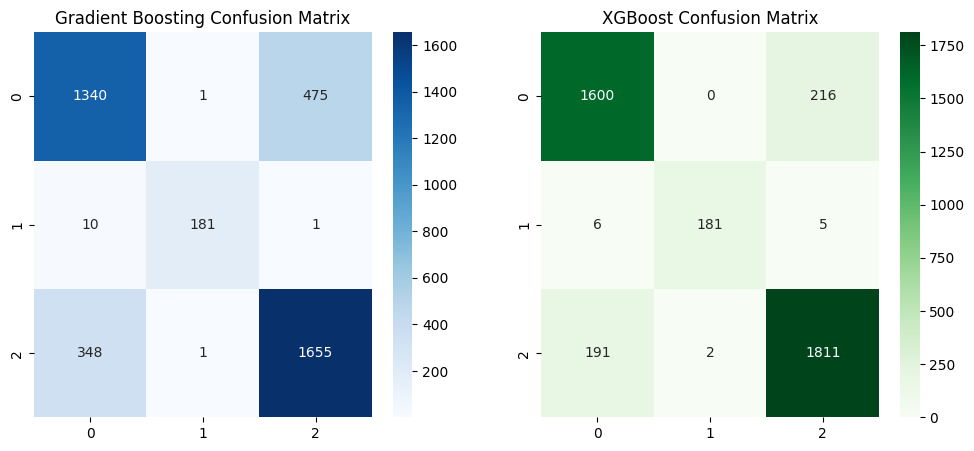

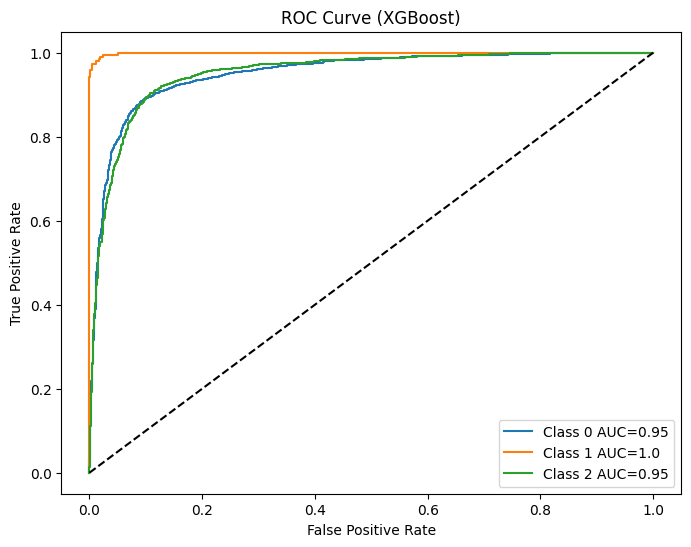

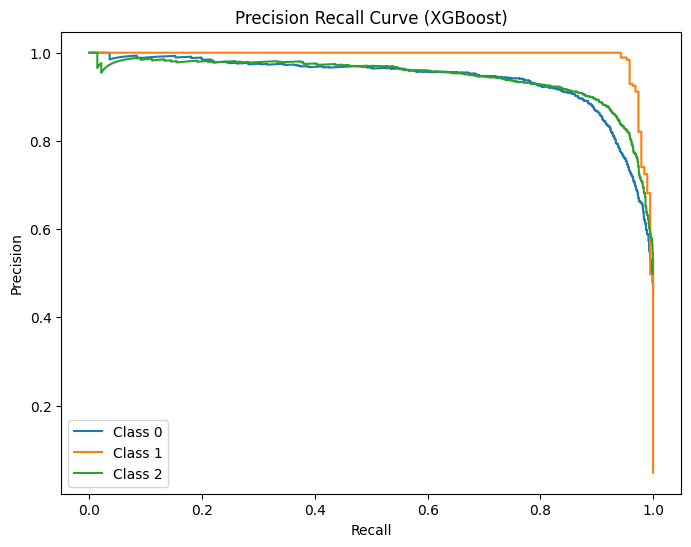

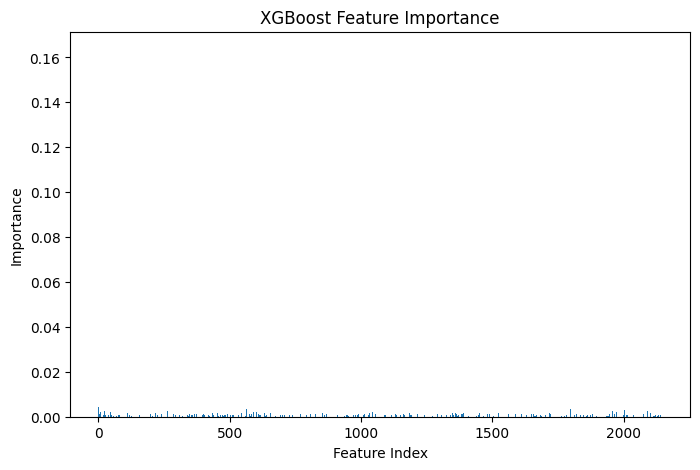

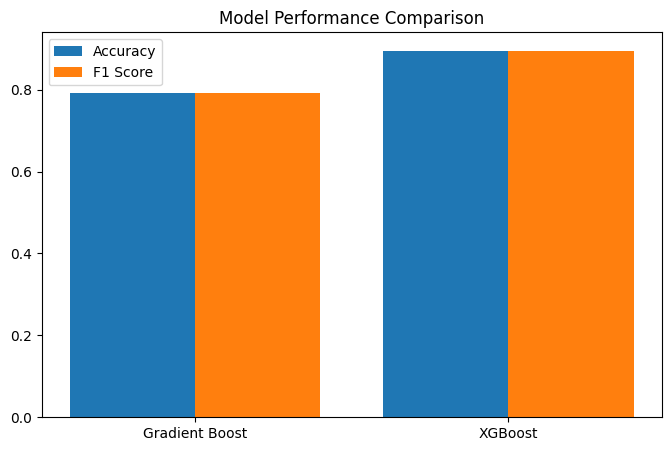

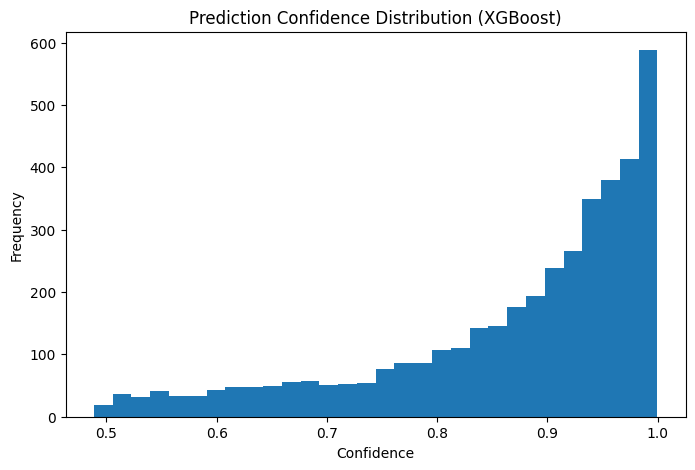

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import (
confusion_matrix,
roc_curve,
auc,
precision_recall_curve,
accuracy_score,
f1_score
)

# ===== CONFUSION MATRICES =====

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.heatmap(
confusion_matrix(y_test,y_pred2),
annot=True,
fmt='d',
cmap="Blues"
)

plt.title("Gradient Boosting Confusion Matrix")

plt.subplot(1,2,2)

sns.heatmap(
confusion_matrix(y_test,y_pred4),
annot=True,
fmt='d',
cmap="Greens"
)

plt.title("XGBoost Confusion Matrix")

plt.show()


# ===== ROC CURVES =====

from sklearn.preprocessing import label_binarize

classes = np.unique(y_test)

y_test_bin = label_binarize(y_test,classes=classes)

plt.figure(figsize=(8,6))

for i in range(len(classes)):

    fpr,tpr,_ = roc_curve(
    y_test_bin[:,i],
    y_prob4[:,i]
    )

    plt.plot(
    fpr,
    tpr,
    label="Class "+str(i)+" AUC="+str(round(auc(fpr,tpr),2))
    )

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve (XGBoost)")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()


# ===== PRECISION RECALL CURVES =====

plt.figure(figsize=(8,6))

for i in range(len(classes)):

    precision,recall,_ = precision_recall_curve(
    y_test_bin[:,i],
    y_prob4[:,i]
    )

    plt.plot(
    recall,
    precision,
    label="Class "+str(i)
    )

plt.title("Precision Recall Curve (XGBoost)")

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.legend()

plt.show()


# ===== FEATURE IMPORTANCE =====

model = model_pipeline4.named_steps['model']

importances = model.feature_importances_

plt.figure(figsize=(8,5))

plt.bar(
range(len(importances)),
importances
)

plt.title("XGBoost Feature Importance")

plt.xlabel("Feature Index")

plt.ylabel("Importance")

plt.show()


# ===== MODEL COMPARISON =====

gb_acc = accuracy_score(y_test,y_pred2)

xgb_acc = accuracy_score(y_test,y_pred4)

gb_f1 = f1_score(y_test,y_pred2,average='weighted')

xgb_f1 = f1_score(y_test,y_pred4,average='weighted')

models = ["Gradient Boost","XGBoost"]

acc = [gb_acc,xgb_acc]

f1 = [gb_f1,xgb_f1]

x = np.arange(len(models))

plt.figure(figsize=(8,5))

plt.bar(x-0.2,acc,0.4,label="Accuracy")

plt.bar(x+0.2,f1,0.4,label="F1 Score")

plt.xticks(x,models)

plt.title("Model Performance Comparison")

plt.legend()

plt.show()


# ===== CONFIDENCE DISTRIBUTION =====

plt.figure(figsize=(8,5))

plt.hist(
np.max(y_prob4,axis=1),
bins=30
)

plt.title("Prediction Confidence Distribution (XGBoost)")

plt.xlabel("Confidence")

plt.ylabel("Frequency")

plt.show()

In [19]:
import joblib

# retrain (important even if already trained)
model_pipeline4.fit(X_train, y_train)

# save model safely
joblib.dump(model_pipeline4, "chess_model.pkl", compress=3)

print("Model saved")

Model saved
